# Colley ranking

Description: Construct a Colley ranking of data.
  
Created by Tim Chartier

### Set parameters

gameFilename - game data file, presumed to be in the format from 
the Massey rating data server, which can be found at 
http://www.masseyratings.com/. 

teamFilename - team data file

k - number of teams to print in the final ranking - set to 0 to get all teams

In [44]:
gameFilename = '24games.txt'
teamFilename = '24teams.txt'
k = 102

### Load the team names into an array

In [10]:
import pandas as pd

teamNames = pd.read_csv(teamFilename, header = None)
numTeams = len(teamNames)

### Load the games

In [13]:
# columns of games are:
#	column 0 = days since 1/1/0000
#	column 1 = date in YYYYMMDD format
#	column 2 = team1 index
#	column 3 = team1 homefield (1 = home, -1 = away, 0 = neutral)
#	column 4 = team1 score
#	column 5 = team2 index
#	column 6 = team2 homefield (1 = home, -1 = away, 0 = neutral)
#	column 7 = team2 score
games = pd.read_csv(gameFilename, header = None)
numGames = len(games)

### Create the Colley linear system

In [15]:
import numpy as np

colleyMatrix = 2*np.diag(np.ones(numTeams))
b = np.ones(numTeams)

for i in range(numGames):
    team1ID = games.loc[i, 2] - 1 # subtracting 1 since python indexes at 0
    team1Score = games.loc[i, 4]
    team2ID = games.loc[i, 5] - 1 # subtracting 1 since python indexes at 0
    team2Score = games.loc[i, 7]
    
    colleyMatrix[team1ID, team2ID] -= 1
    colleyMatrix[team2ID, team1ID] -= 1

    colleyMatrix[team1ID, team1ID] += 1
    colleyMatrix[team2ID, team2ID] += 1
    
    if team1Score > team2Score:
        b[team1ID] += 1/2
        b[team2ID] -= 1/2
    elif team1Score < team2Score:
        b[team1ID] -= 1/2
        b[team2ID] += 1/2
    else:  # it is a tie and make 1/2 a win and 1/2 a loss for both teams
        b[team1ID] += 0; # this equates to adding nothing
        b[team2ID] += 0; # clearly this code could be deleted

### Calculate linear system

In [19]:
r = np.linalg.solve(colleyMatrix,b)
iSort = np.argsort(-r)

### Print the ranking of the teams

In [46]:
print('\n\n************** COLLEY Rating Method **************\n')
print('===========================')
print('Rank   Rating    Team   ')
print('===========================')
if k==0:
    numberTeamToPrint = numTeams
else:
    numberTeamToPrint = k

for i in range(numberTeamToPrint):
    print(f'{i+1:4d}   {r[iSort[i]]:.5f}  {teamNames.loc[iSort[i],1]}')

print('')   # extra carriage return



************** COLLEY Rating Method **************

Rank   Rating    Team   
   1   0.95090   10
   2   0.95090   15
   3   0.93966   9
   4   0.92842   3
   5   0.92842   11
   6   0.88910   14
   7   0.88348   6
   8   0.83854   5
   9   0.82168   2
  10   0.81589   Сахипов Амир
  11   0.78648   Шарел Марғұлан
  12   0.75707   Даутов Жан
  13   0.75707   Юркевич Мирон
  14   0.72766   Аманжолов Амирлан
  15   0.72766   Мурат Тимур
  16   0.69825   Маратұлы Әлинұр
  17   0.69825   Роговский Владимир
  18   0.69825   Таңсықбай Абзал
  19   0.68685   8
  20   0.66883   Сайлаубай Бексұлтан
  21   0.65876   13
  22   0.63942   Нәрік Арсен
  23   0.63942   Кеңшілік Ерқанат
  24   0.61001   Касенова Арай
  25   0.61001   Керімхан Әлбар
  26   0.61001   Молдабек Әділбек
  27   0.61001   Әбділдін Әмір
  28   0.61001   Одинцова Анастасия
  29   0.61001   Бисенбаев Мирас
  30   0.59135   12
  31   0.58060   Нурланов Дамир
  32   0.58060   Әміртай Әлимарғұлан
  33   0.58060   Егеубаев Динмухам

### Calculate predictability of method

In [25]:
numberCorrectPredictions = 0
for i in range(numGames):
    team1ID = games.loc[i, 2] - 1 
    team1Score = games.loc[i, 4]
    team2ID = games.loc[i, 5] - 1 
    team2Score = games.loc[i, 7]
    
    if team1Score > team2Score and r[team1ID] > r[team2ID]:
        numberCorrectPredictions += 1
    elif team2Score > team1Score and r[team2ID] > r[team1ID]:
        numberCorrectPredictions += 1
    elif team1Score == team2Score and r[team1ID] == r[team2ID]:
        numberCorrectPredictions += 1

print(f'Predictability: {numberCorrectPredictions/numGames*100:.2f}%') 


Predictability: 88.12%


In [27]:
ProblemFile = open("Problem ranking COLLEY", "w")
for i in range(15):
    index = np.where(iSort == i)[0][0]
    ProblemFile.write('%3i,%3i, %f\n' %(i+1,index+1, r[iSort[index]]))
ProblemFile.close()

## Students

In [30]:
#teamNames - all teams. column 0 - index, column 1 - player. rows 0-14 - problems
studNames=teamNames.iloc[15:,1] #array with students only(ranked by points)
#r - ratings by indexes
studRating=r[15:]#rating of students
pointFilename='24points.txt' #points
points=pd.read_csv(pointFilename, header=None)
studPoints=points.iloc[:,16]
studNames=studNames.reset_index(drop=True)


In [32]:
## Rank comparision 

=== Correlation Between Olympiad Ranking and Colley ===
Spearman Rank Correlation: 0.986
Kendall's Tau: 0.920



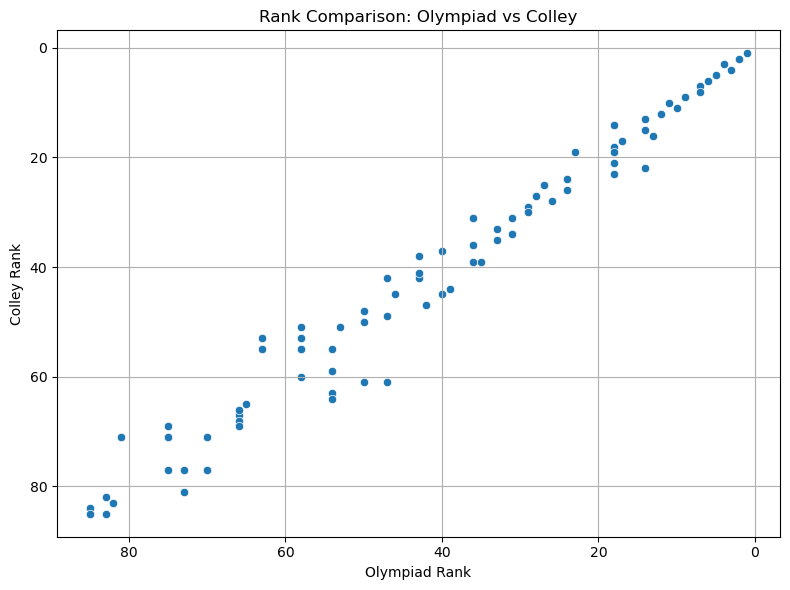

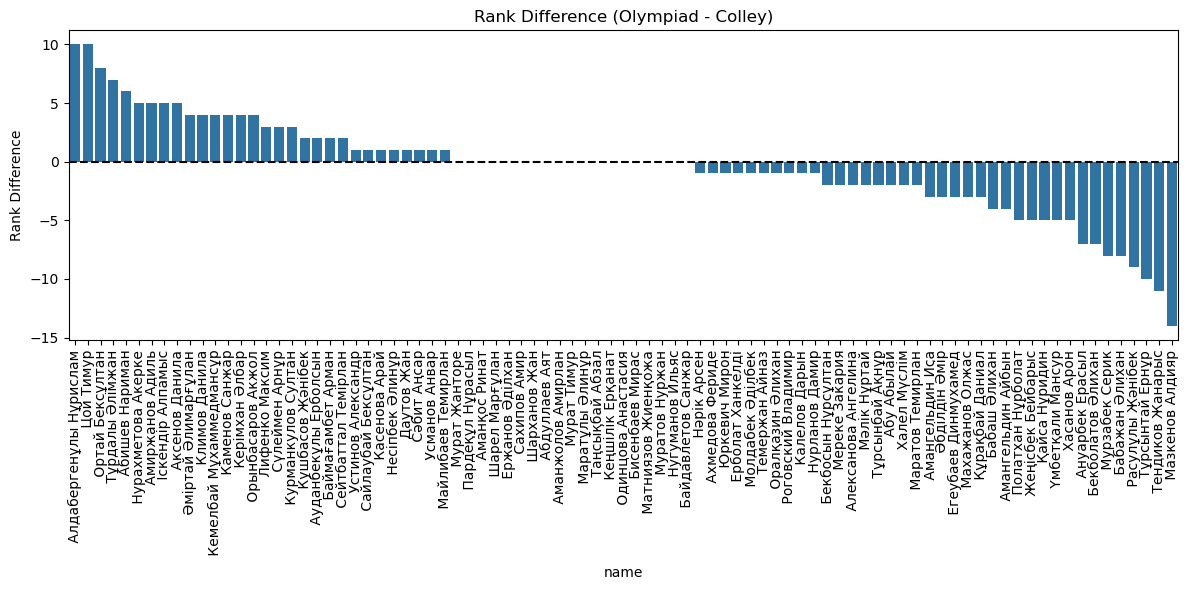

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kendalltau

# ---- 1. Your Data as Arrays ----
names = studNames  # Add all 87 names here
pointSum = studPoints                  # Replace with actual point scores
methodA = pd.Series(r[15:]).reset_index(drop=True)      # Replace with your Method A ratings
# ---- 2. Create DataFrame ----
data = pd.DataFrame({
    'name': names,
    'pointSum': pointSum,
    'methodA': methodA
})


# ---- 3. Compute Rankings ----
data['rank_score'] = data['pointSum'].rank(ascending=False, method='min').astype(int)
data['rank_methodA'] = data['methodA'].rank(ascending=False, method='min').astype(int)
data['rank_diff'] = data['rank_score'] - data['rank_methodA']

# ---- 4. Correlation Analysis ----
spearman_corr, _ = spearmanr(data['rank_score'], data['rank_methodA'])
kendall_corr, _ = kendalltau(data['rank_score'], data['rank_methodA'])

print("=== Correlation Between Olympiad Ranking and Colley ===")
print(f"Spearman Rank Correlation: {spearman_corr:.3f}")
print(f"Kendall's Tau: {kendall_corr:.3f}\n")

# ---- 5. Scatter Plot ----
plt.figure(figsize=(8, 6))
sns.scatterplot(x='rank_score', y='rank_methodA', data=data)
plt.title("Rank Comparison: Olympiad vs Colley")
plt.xlabel("Olympiad Rank")
plt.ylabel("Colley Rank")
plt.grid(True)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ---- 6. Rank Difference Bar Plot ----
plt.figure(figsize=(12, 6))
sns.barplot(x='name', y='rank_diff', data=data.sort_values('rank_diff', ascending=False))
plt.xticks(rotation=90)
plt.title("Rank Difference (Olympiad - Colley)")
plt.ylabel("Rank Difference")
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


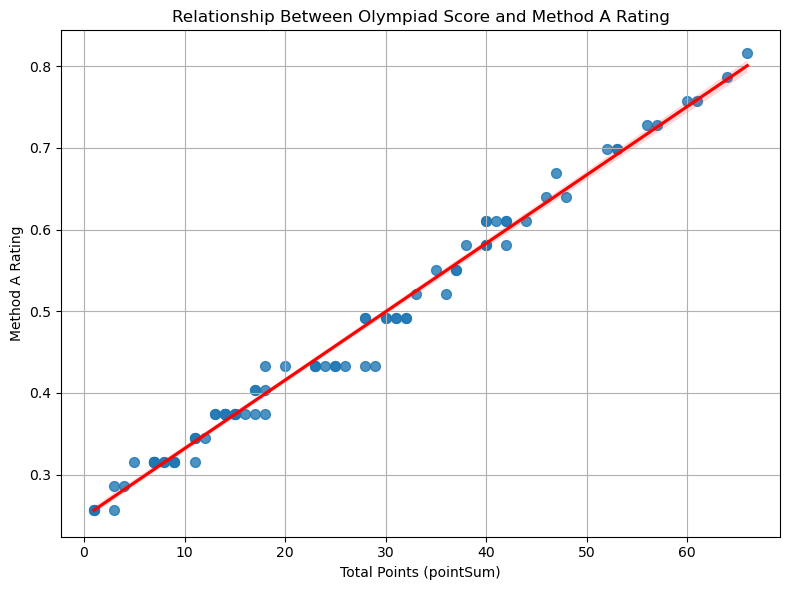

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.regplot(x='pointSum', y='methodA', data=data, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title("Relationship Between Olympiad Score and Method A Rating")
plt.xlabel("Total Points (pointSum)")
plt.ylabel("Method A Rating")
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Reshape inputs for sklearn
X = data['pointSum'].values.reshape(-1, 1)
y = data['methodA'].values

# Fit linear model
model = LinearRegression()
model.fit(X, y)
predicted = model.predict(X)

# Calculate residuals
data['residual'] = y - predicted

# Define outliers: residuals greater than 2 standard deviations
threshold = 2 * np.std(data['residual'])
outliers = data[abs(data['residual']) > threshold]

print(f"Number of outliers: {len(outliers)}")
print(outliers[['name', 'pointSum', 'methodA', 'residual']])


Number of outliers: 4
                   name  pointSum   methodA  residual
34    Амангельдин Айбын        29  0.433541 -0.057467
37      Құрақбай Даниал        28  0.433541 -0.049092
38        Қайса Нұридин        26  0.433541 -0.032342
46   Нурахметова Акерке        18  0.433541  0.034657


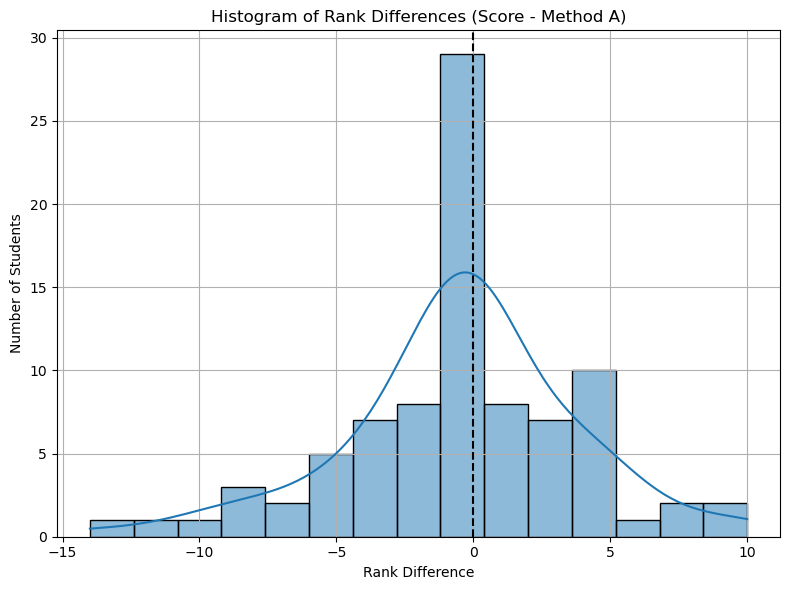

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(data['rank_diff'], bins=15, kde=True)
plt.title("Histogram of Rank Differences (Score - Method A)")
plt.xlabel("Rank Difference")
plt.ylabel("Number of Students")
plt.axvline(0, color='black', linestyle='--')
plt.grid(True)
plt.tight_layout()
plt.show()


In [42]:
# Add helper columns
data['promotion'] = data['rank_diff'] > 0
data['demotion'] = data['rank_diff'] < 0

# Top 10 promoted
top_promoted = data.sort_values('rank_diff', ascending=False).head(10)
print("Top 10 Students Promoted by Method A:")
print(top_promoted[['name', 'pointSum', 'methodA', 'rank_score', 'rank_methodA', 'rank_diff']])

# Top 10 demoted
top_demoted = data.sort_values('rank_diff').head(10)
print("\nTop 10 Students Demoted by Method A:")
print(top_demoted[['name', 'pointSum', 'methodA', 'rank_score', 'rank_methodA', 'rank_diff']])

Top 10 Students Promoted by Method A:
                       name  pointSum   methodA  rank_score  rank_methodA  \
62   Алдабергенұлы Нұрислам        13  0.374717          63            53   
80                Цой Тимур         5  0.315894          81            71   
63          Ортай Бексұлтан        13  0.374717          63            55   
59          Тұрдалы Әлімжан        14  0.374717          58            51   
79           Абишев Нариман         7  0.315894          75            69   
46       Нурахметова Акерке        18  0.433541          47            42   
44          Амиржанов Адиль        23  0.433541          43            38   
36         Іскендір Алпамыс        28  0.492364          36            31   
58           Аксенов Данила        14  0.374717          58            53   
22      Әміртай Әлимарғұлан        38  0.580600          23            19   

    rank_diff  
62         10  
80         10  
63          8  
59          7  
79          6  
46          5  
44

In [51]:
data[30:50]

,name,pointSum,methodA,rank_score,rank_methodA,rank_diff,residual,promotion,demotion
30,Нугуманов Ильяс,31,0.492364,31,31,0,-0.015393,False,False
31,Махажанов Олжас,31,0.492364,31,34,-3,-0.015393,False,True
32,Бекбосын Нұрсұлтан,30,0.492364,33,35,-2,-0.007018,False,True
33,Байдавлетов Санжар,30,0.492364,33,33,0,-0.007018,False,False
34,Амангельдин Айбын,29,0.433541,35,39,-4,-0.057467,False,True
35,Шарханов Жан,28,0.492364,36,36,0,0.009732,False,False
36,Іскендір Алпамыс,28,0.492364,36,31,5,0.009732,True,False
37,Құрақбай Даниал,28,0.433541,36,39,-3,-0.049092,False,True
38,Қайса Нұридин,26,0.433541,39,44,-5,-0.032342,False,True
39,Курманкулов Султан,25,0.433541,40,37,3,-0.023967,True,False


In [59]:
points.iloc[30:60, ::]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
30,Нугуманов Ильяс,7,0,0,7,0,1,7,0,0,0,0,2,7,0,0,31
31,Махажанов Олжас,7,0,0,0,0,1,7,7,0,0,0,7,2,0,0,31
32,Бекбосын Нұрсұлтан,7,0,0,6,0,2,7,0,0,0,0,1,7,0,0,30
33,Байдавлетов Санжар,7,0,0,6,1,0,7,0,0,0,2,7,0,0,0,30
34,Амангельдин Айбын,7,0,0,7,0,2,7,2,0,0,2,0,2,0,0,29
35,Шарханов Жан,7,0,0,7,0,1,7,0,0,0,0,1,5,0,0,28
36,Іскендір Алпамыс,7,0,0,7,0,1,7,0,0,0,0,1,5,0,0,28
37,Құрақбай Даниал,2,7,0,2,0,0,7,7,0,0,0,1,2,0,0,28
38,Қайса Нұридин,7,0,0,7,0,1,7,0,0,0,0,2,2,0,0,26
39,Курманкулов Султан,7,0,0,7,0,0,7,2,0,0,0,0,2,0,0,25
